### Step 1: Import Libraries and load the environment variables

In [ ]:
import os
from openai import OpenAI
from dotenv import load_dotenv
from IPython.display import Markdown, display
import gradio as gr
import json
import random
import requests
from pprint import pprint
import chromadb
import uuid

load_dotenv
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if OPENAI_API_KEY is None:
    raise Exception("API key is missing")

client = OpenAI()



### Step 2: RAG (Retrieval Augmented Generation) Preparation

In [20]:
document_overview = """
Sammy Gutierrez is a Software Engineer, musician, and used to work as a elementary school music teacher. He lived most of his life in the greater Houston area but is currently living in Vail, Colorado.
He has a Bachelors of Music Education but completed a 1000+ hour coding bootcamp where he immersed himself in learning about Software Engineering.

Additional Info:
- In his time working with students, he has led multiple ensembles such as choir and percussion ensemble as well as put on numerous productions such as winter and spring choir performances, grade level musicals, and even conducted a choir of 120 5th graders at Houston Astros game. 
- In his time working with software, he helped developed the web application for a augmented reality work instructions and management solution. Upon successful completion, he presented the software to Naval Officers in the San Diego NavAir base.
Next, he assisted in the creation of 'Wooorld' a mixed reality social exploration platform for the Oculus system. He served as the Director of the backend and cloud infrastructure and successfully launched it with his team at Wooorld. 
Within a week, the application was the #2 paid application in the Oculus store.
- What drives him: He genuinely loves solving problembs. Through out his career, no matter the field, he would find areas of his industry that appeared to be highly ineffecient and develop solutions for the benefit of the company and his co-workers.
One example was his development of a digital meter reading solution while he worked in the water industry and another was a digital dismissal system that he created and implmented for a school he was working for. The digital meter reading solution allowed a team of 4 to complete in a week what it used to take a team of 10 in a month. 
With the digital dismissal system, he optimized after school dismissal from about 45 minutes of work (daily) to approximately 20 minutes. 
- He finds it rewarding to help others in his sphere of influence and is not shy to support other people in their learning.

- Communication style: Direct but friendly. Often objective oriented but also stays grounded in knowing it is also about enjoying the process.
"""

In [21]:
document_education = """
App Academy Bootcamp
- Time attended - October 2019 - March 2020
- Studied: Software Engineering and Full Stack Development
- Summary: 1000+ hours immersive software engineering course with focus on full stack web development covering Ruby, SQL/PostgreSQL, Rails, Javascript, React/Redux, HTML, CSS, MongoDb, Express, Node Js, Docker. App Academy also builds on a core foundation of data structures and algorithms.

Houston Baptist University
- Time Attended - August 2008 - May 2012
- Degree - Bachelor of Music Education
- GPA - 3.59 - Cum Laude Graduate
- Activities and Societies - Advanced Jazz Guitar Ensemble, Alpha Chi National Honor Society, TMEA, Swing Dancing club, Pep Band Leader, Symphonic Band Orchestral Bassist, RA Assistant

Wharton County Junior College
- Degree - Associate's of Music
Jul 2006 – May 2008

Activities and societies: Choir, Jazz Band
Awards: Dean's List Recipient

Super Data Science
Studied AI Engineering
Aug 2026 – Oct 2026
Skills: Artificial Intelligence (AI), Large Language Models (LLM)
"""

In [22]:
document_professional_experience = """
Sammy Gutierrez
(832) 951-9174
samgutierrez335@gmail.com
linkedin.com/in/sammy-gutierrez
Full Stack Software Engineer with 5+ years of experience building scalable systems and real-time architectures.
Brings strong cross-functional communication and user-centered approach to problem-solving.
SKILLS
Languages: JavaScript, TypeScript, Python, Ruby, C#, SQL
Frontend: React, Redux, WebSockets, Axios, GraphQL, MUI, HTML, CSS
Backend: Node.js, Express, Passport, Ruby on Rails, REST APIs, PM2
Cloud & DevOps: Amazon Web Services, Google Cloud Platform, Docker, NGINX, HTTPS / SSL
Databases: MongoDB, PostgreSQL, Microsoft SQL Server
Tools & Testing: OpenAI, LLMLite, Git, Postman, Miro, Notion, JMeter, Jest, RSpec, Amplitude
EXPERIENCE
Independent Consultant | Oct 2024 – Current
● Supported previous employer (Sharp Vision Software) by assisting in improvements for the AVARIS
platform under tight production deadlines
● Wordpress Website Creation, Domain Registry and DNS setting management.
Software Engineer – GHG Corp | Aug 2023 – Aug 2024
● Led migration of a legacy 20–year–old application from AccuRev to a modern stack using React,
TypeScript, and GraphQL improving maintainability and release reliability
● Designed and implemented core application features by integrating Java-based GraphQL resolvers with
Microsoft SQL to improve data access and performance across various devices
Full Stack Developer – Wooorld (Mixed Reality Social Platform) | Aug 2021 – Sep 2022
● Served as the decision maker for all backend, database, and cloud infrastructure development
● Architected scalable backend systems using Node.js, AWS EC2, SQS, and Lambda to support real–time
user interactions, removing race conditions with networking protocols.
● Optimized Oculus Quest map rendering with K-Means clustering and MongoDB aggregations, scaling
visible pins from 10–20 to 2,000+ (100x+ improvement)
● Conducted live demos in English and Spanish for 600+ users at Mobile World Congress 2022
Full Stack Developer – Sharp Vision Software | Jun 2020 – Aug 2021
● Built an augmented reality work instruction platform that brings a modernized approach to asset
maintenance and assembly, drastically reducing the overhead of paper assets management.
● Assisted in the construction of a headless model processing pipeline that optimizes 3d models and
substantially reduced the amount of storage needed per model while maintaining visual integrity
● Presented a live demonstration of completed software to the U.S. Navy stakeholders
EDUCATION
Super Data Science
AI Engineering Course (anticipated completion - October 1st 2026)
Coursera
Google AI Professional Certificate
App Academy
Full Stack Software Engineering Program (1000+ hours, <3% acceptance rate)
Houston Christian University
Bachelor of Music in Music Education, Cum Laude

Lower School Music Teacher

Vail Mountain School · Full-time

Aug 2024 - Jun 2026 · 1 yr 11 mos

Vail, Colorado, United States · On-site

● Design and deliver a K–3 general music curriculum combining Kodály-based pedagogy, Orff arrangements, and foundational instrumental instruction.
● Integrate musical theater techniques into K–3 instruction to support the broader K–12 performing arts program. 
● Co-direct multiple student productions annually, including 30–60 minute MTI Disney musicals, a Kindergarten musical, and a 3rd–4th grade play, fostering community engagement and school-wide collaboration..
● Actively contribute to school-wide initiatives, including supporting the athletic department and serving on the Talent Acquisition and Retention Committee.
● Lead extracurricular robotics and programming clubs for 3rd–5th grade students, promoting STEM learning and foundational coding skills.

Harris Computer logo
Software Engineer

Harris Computer · Full-time

Aug 2023 - Aug 2024 · 1 yr 1 mo

Remote / Webster TX · Hybrid

*Downsized upon company acquisition*

● Assisting with web app color and design changes.
● Wireframing/Designing of new UX/UI in figma.
● Created modules using React / Typescript / GraphQL that were integrated with existing application.
● Designed GraphQL Queries and Mutations and also created a temporary backend server to maintain frontend progress until backend API was set up. 
● Implementation and customization of various MUI components such as Data Grid Premium, Date Range Pickers, Modals, and Alerts.
● Assessment of client customization specifications and deadline planning to ensure the successful delivery of features.

 Unit Testing, AccuRev and +6 skills

Self Employed

Freelance · Freelance

Oct 2022 - Aug 2023 · 11 mos

United States

 Version Control

Wooorld logo
Full Stack Developer

Wooorld · Full-time

Aug 2021 - Sep 2022 · 1 yr 2 mos

Remote

● Lead interactive demos during Mobile World Congress 2022 in Barcelona for approximately 
 600 users.
● Set up multiple AWS EC2 instances running Node.js HTTPS servers and a React Web Application protected with Windows security groups/policies, express routing, and an NGINX reverse proxy to ensure secure traffic to the backend infrastructure. 
● Managed company SaaS and IaaS through AWS IAM, SQS, SSM, and Lambda functions.
● Created features utilizing Google Cloud Platform's Google Sheets, Gmail, and Maps API.
● Wrote JMETER user flow tests to ensure server performance under high-traffic scenarios.  
● Configured PM2 Plus for the resiliency and reliability of our applications and services as well as metrics collection. 
● Wrote and documented RESTful API for ease of understanding from team members.
● Created and managed a Postman Team Workspace to assist in testing endpoints and websockets in local, development, and production environments.
● Coded in a microservice architecture to increase resilience and scalability of endpoints.
● Manage 3 separate MongoDB databases including database access and credential administration, and set up an automated backup/migration script.
● Utilized MongoDb Compass to build and test aggregations as well as analyze query and aggregation performance.
● Gathered feedback from users directly through Discord channels, Google Forms, and coordinated group events. Gained insight on user behavior indirectly from Analytic tools such as Amplitude and Mixpanel.

 Version Control

Full Stack Developer

Sharp Vision Software · Full-time

Jun 2020 - Jul 2021 · 1 yr 2 mos

Houston, Texas, United States

● In a small Agile team, we provided a solution for NavAir (Contract Number: N68335-19-C-0533) to decimate 3d models, create digital instructions with embedded 3d models (and other media), and assign and monitor work instruction completion. 
● Using a UI design, I gave breath to our web application using clean modular React components. 
● I leveraged flexbox attributes, relative units, media queries, and content toggling to build a responsive web application that was engaging and maximized productivity and accessibility from 800x800 to 4k resolution. 
● Research and coordinated with our clients and teammates to optimize our solutions UX/UI ensuring we were always in alignment with our clients' use cases.
● Implemented custom User Authentication using BCrypt hashing, protected our application and backend API endpoints utilizing Passport/JWT strategy and custom/protected routes on the front end (using user roles) to increase the overall security of the application.
● Set up Abort Controllers to optimize memory usage in frontend API requests.

 Version Control

Katy ISD logo
Katy ISD

3 yrs

Music Teacher

Aug 2018 - Jul 2019 · 1 yr

Bethke Elementary

Inspired students to learn to code by facilitating an hour of guided programming, robotics, and animation.
● Devised system for optimizing after school dismissal of over 700 “car rider” students.
● Recognized by a lead district technology developer for my use of technology in my classroom and which led to the co-development and leading of a technology seminar for the district.

KSAT Bilingual Music Teacher

Full-time

Jun 2018 - Jul 2018 · 2 mos

Bethke Elementary

● Taught a curriculum tailored towards Pre-K, K, 1st, and 2nd-grade ELL and ESL students.

Music Teacher

Full-time

Aug 2016 - Jul 2018 · 2 yrs

Tom Wilson Elementary

● Taught an exciting and Kodaly structured music class for approximately 650 K-5th grade students (half of the school/weekly). 
● Collaborated with another music teacher to develop our yearly curriculum and met weekly to ensure students were progressing appropriately.
● Responsible for recruiting, rehearsing, and conducting the school choir as well as planning the choir's extra-curricular events/performances. 
● Rehearsed and conducted 4th-graders in a grade-level wide musical. I work with my partner teacher to audition and prepare the main cast, rehearse songs and choreography with the choir, locate/make/purchase props, and coordinate volunteer efforts. 
● Worked with the entire 2nd-grade level to learn various folk dances that are performed for the school. Parents were invited to participate in a portion of the evening performance and it was also our job to teach the parents who were wanting to join in.
● Provided mentorship to a new music teacher
● Led a district-wide music technology seminar.

KSAT Program - Bilingual Music Educator

Full-time

Jun 2017 - Jul 2017 · 2 mos

Memorial Parkway Elementary, Katy Texas

● Taught a curriculum tailored towards Pre-K, K, 1st, and 2nd-grade ELL and ESL students.

Lead Guitarist

Memorial Drive Baptist Church

Jan 2011 - Apr 2017 · 6 yrs 4 mos

Memorial Drive Baptist Church

● Analyzed and prepared lead guitar and occasionally rhythm guitar parts from Contemporary and Traditional Christian Worship music.
● After preparation, music was rehearsed with a six-person band
● Performed music for the weekly Sunday service as well as special holiday events.

Elementary Music Teacher

Galena Park ISD · Full-time

Jan 2015 - Aug 2016 · 1 yr 8 mos

Sam Houston Elementary School

● Pioneered a solution to our afterschool dismissal procedures that utilized Google Docs/Sheets to increase the efficiency and safety of student dismissal. The system allowed outside teachers to compile a cloud-based list of student car numbers while simultaneously sharing/updating the list with teachers monitoring students inside the building.
● Taught 1 hour music classes based on Silver Burdett's Making Music Textbook for for approximately 1000 K-5th grade students (40-45 students per class).
● I rehearsed music with each individual grade level during their respective class time and then perform their music at scheduled PTA meetings.
● Created the "Percussion Ensemble" and "Honor Choir" to increase afterschool participation. 
● I auditioned, selected, and in joint efforts with other district music teachers, rehearsed District Honor Choir members. I hosted rehearsals at our campus periodically and assisted directors during rehearsals.
● PTA Reflections Chairperson - I helped promote the National PTA contest in our school as well as our school community. Researching guidelines, submission procedures, and relaying them to the students and teachers interested in participating. 
● I met with students desiring to submit musical compositions for the contest for guidance. One of the musical composition entries won at the district level and advanced to the state level.
● Served on the 'Foundations Committee' to discuss concerns in the school and collaborated on plans of action to resolve concerns.  
● I served as grade-level chair of the enrichment team facilitating communications between the team, classroom teachers, and administration. We also researched and implemented strategies for improving instruction and classroom management across the enrichment classes.
● Fostered a connection with the Houston Grand Opera and through efforts on both parts we afforded the students an opportunity to see an “Opera To Go” production at a Houston Community College campus.

Department Developer/Supervisor

Municipal Operation and Consulting · Full-time

Oct 2012 - Dec 2014 · 2 yrs 3 mos

Katy, Tx

● Led water utility operations across approximately nine Municipal Utility Districts (MUDs) in Katy, Cypress, and Houston by scheduling and coordinating work orders, supporting field operations, and earning a Texas Class D Water Operator License.
● Trained and mentored new water utility operators, coordinated work, and responded to emergency on-call situations to maintain reliable water service.
● Investigated Non-Revenue Water (NRW) by identifying and researching real and apparent losses, supporting leak detection efforts, improving meter accuracy, and helping districts better account for water production and consumption.
● Directed the transition of the Katy branch from manual paper reading to electronic meter reading by developing the implementation plan, selecting districts for phased deployment, interviewing and training personnel, and supervising field operations.
● Improved meter-reading efficiency by approximately 10× through the successful implementation of the electronic meter reading program, while providing regular progress reports and project updates to the Branch Manager, CEOs and other stakeholders. 
● Partnered with software engineers as the operations subject-matter expert, translating utility workflows into software requirements, providing UI/UX feedback, validating new features, and identifying and resolving application defects.

Guitar Center logo
Guitar Center Studio Instructor

Guitar Center · Freelance

Apr 2013 - Aug 2013 · 5 mos

Katy, Tx

Guitar Instructor

Collin’s Music Company · Freelance

Mar 2012 - Jan 2013 · 11 mos

Richmond, Texas, United States

Lead Guitarist

Spirit of Life · Freelance

Jun 2010 - Jan 2013 · 2 yrs 8 mos

Sugarland, Texas

Houston Christian University logo
Houston Christian University

3 yrs 5 mos

Student Teaching

Internship

Jan 2012 - May 2012 · 5 mos

Houston · On-site

Dorm Resident Assistant

Part-time

Jun 2011 - May 2012 · 1 yr

Houston, Texas, United States

ITS Department

Part-time

Jan 2009 - Jun 2011 · 2 yrs 6 mos

Houston, Texas, United States

● Diagnosed and Repaired faculty and students' desktops/laptops.
● Assisted in Networking Operations
● Provided technical support to faculty and students over the phone.
● Responded to technical emergencies experienced by faculty members during classroom instruction
● Helped in setting up of faculty offices as well as set up audio/video equipment for special events.

"""

In [23]:
#Chunk the document
def chunk_document(
    document: str,
    chunk_size: int = 250,
    overlap: int = 50,
) -> list[str]:

    # Basic validation.
    if not document:
        return []

    if chunk_size <= 0:
        raise ValueError("chunk_size must be greater than 0")

    if overlap < 0 or overlap >= chunk_size:
        raise ValueError(
            "overlap must be greater than or equal to 0 "
            "and less than chunk_size"
        )

    chunks = []

    start = 0
    document_length = len(document)

    while start < document_length:

        # ---------------------------------------------------------
        # Determine the maximum point where this chunk can end.
        # ---------------------------------------------------------

        max_end = min(
            start + chunk_size,
            document_length
        )

        # If this is the final piece of the document, we're done.
        if max_end == document_length:
            chunks.append(document[start:max_end].strip())
            break

        # ---------------------------------------------------------
        # We don't necessarily want to cut exactly at max_end.
        #
        # Look backward for a natural boundary.
        #
        # We only consider boundaries occurring after halfway
        # through the intended chunk. This prevents us from creating
        # tiny chunks just because we found an early paragraph break.
        # ---------------------------------------------------------

        halfway = start + (chunk_size // 2)

        cut = None

        # ---------------------------------------------------------
        # 1. Prefer a paragraph break.
        #
        # A paragraph break is represented by two newlines:
        #
        #     paragraph one\n\nparagraph two
        # ---------------------------------------------------------

        paragraph_break = document.rfind(
            "\n\n",
            halfway,
            max_end
        )

        if paragraph_break != -1:
            cut = paragraph_break + 2

        # ---------------------------------------------------------
        # 2. If there wasn't a paragraph break, look for a newline.
        # ---------------------------------------------------------

        if cut is None:

            newline = document.rfind(
                "\n",
                halfway,
                max_end
            )

            if newline != -1:
                cut = newline + 1

        # ---------------------------------------------------------
        # 3. If there wasn't a newline, look for the end of a
        #    sentence.
        #
        # We consider ., !, and ? followed by whitespace as
        # reasonable sentence boundaries.
        # ---------------------------------------------------------

        if cut is None:

            for position in range(max_end - 1, halfway - 1, -1):

                if document[position] in ".!?":

                    # Make sure this punctuation actually ends
                    # a sentence rather than appearing inside a
                    # word or abbreviation.
                    if (
                        position + 1 == document_length
                        or document[position + 1].isspace()
                    ):
                        cut = position + 1
                        break

        # ---------------------------------------------------------
        # 4. Finally, fall back to a space.
        #
        # This prevents us from cutting in the middle of a word.
        # ---------------------------------------------------------

        if cut is None:

            space = document.rfind(
                " ",
                halfway,
                max_end
            )

            if space != -1:
                cut = space + 1

        # ---------------------------------------------------------
        # If no natural boundary exists after halfway, use the
        # maximum chunk size.
        #
        # This is important because we must guarantee that the
        # algorithm continues making progress.
        # ---------------------------------------------------------

        if cut is None:
            cut = max_end

        # ---------------------------------------------------------
        # Create the chunk.
        # ---------------------------------------------------------

        chunk = document[start:cut].strip()

        if chunk:
            chunks.append(chunk)

        # ---------------------------------------------------------
        # Move to the beginning of the next chunk.
        #
        # Instead of starting exactly where the previous chunk
        # ended, move backward by `overlap` characters.
        #
        # Example:
        #
        # previous chunk ends at 500
        # overlap = 50
        #
        # next chunk starts at 450
        #
        # Therefore characters 450-500 appear in both chunks.
        # ---------------------------------------------------------

        start = cut - overlap

        # Prevent accidental infinite loops.
        if start <= 0 and cut > 0:
            start = cut - overlap

    return chunks

In [ ]:
documents = [
    { "text": document_overview, "source": "Sammy's Overview"},
    { "text": document_education, "source": "Sammy's Education"},
    { "text": document_professional_experience, "source": "Sammy's Professional Experience"}
]

chunks = []
ids = []
metadatas = []

for doc in documents:
    #prepare the list
    chunks_ = chunk_document(doc["text"], chunk_size=300, overlap=30)
    ids_ = [str(uuid.uuid4()) for _ in range(len(chunks_))]
    metadatas_ = [{"source": doc["source"], "chunk_index": i} for i in range(len(chunks_))]

    #Add to main lists
    chunks.extend(chunks_)
    ids.extend(ids_)
    metadatas.extend(metadatas_)

for i, chunk in enumerate(chunks):
    display(Markdown(f"### Chunk {i+1} (ID: {ids[i]}, Source: {metadatas[i]['source']}, Index: {metadatas[i]['chunk_index']})"))
    display(Markdown(chunk))

### Chunk 1 (ID: 4e9951a6-a1f6-40b7-bda8-b5b896ecc768, Source: Sammy's Overview, Index: 0)

Sammy Gutierrez is a Software Engineer, musician, and used to work as a elementary school music teacher. He lived most of his life in the greater Houston area but is currently living in Vail, Colorado.

### Chunk 2 (ID: d59f2f6f-8596-4f9e-a870-a62d7d9db5c3, Source: Sammy's Overview, Index: 1)

tly living in Vail, Colorado.
He has a Bachelors of Music Education but completed a 1000+ hour coding bootcamp where he immersed himself in learning about Software Engineering.

### Chunk 3 (ID: 4a616019-e703-4bbd-abfc-12c6db4edf01, Source: Sammy's Overview, Index: 2)

...

ite

Dorm Resident Assistant

Part-time

Jun 2011 - May 2012 · 1 yr

Houston, Texas, United States

ITS Department

Part-time

Jan 2009 - Jun 2011 · 2 yrs 6 mos

Houston, Texas, United States

### Chunk 77 (ID: bb1a6b97-504e-4d00-93ef-bdfe62a331a7, Source: Sammy's Professional Experience, Index: 62)

ouston, Texas, United States

● Diagnosed and Repaired faculty and students' desktops/laptops.
● Assisted in Networking Operations
● Provided technical support to faculty and students over the phone.
● Responded to technical emergencies experienced by faculty members during classroom instruction

### Chunk 78 (ID: 4094623e-5122-4b0a-b9ef-8a85aaec4d01, Source: Sammy's Professional Experience, Index: 63)

during classroom instruction
● Helped in setting up of faculty offices as well as set up audio/video equipment for special events.

In [25]:
# Generate embeddings for all chunks
#whatever model you use for embedding you should use the same model for retrieval and generation.
# this is important because of the way different models will result in different number of dimensions in the embedding vector. 
# If you use different models for embedding and retrieval, the similarity search will not work properly.
response = client.embeddings.create(
    model="text-embedding-3-small",
    input = chunks
)
embeddings = [item.embedding for item in response.data]


In [26]:
#verify embeddings
pprint(f"Generated {len(embeddings)} embeddings for {len(chunks)} chunks.")
pprint(f"Each embedding has {len(embeddings[0])} dimensions.")

'Generated 78 embeddings for 78 chunks.'
'Each embedding has 1536 dimensions.'


Cluster 0 summary: Sammy Gutierrez exemplifies a unique blend of artistic and technical talents, transitioning from a career in music education to software engineering. With a strong foundation in music, having conducted large ensembles and organized performances, he furthered his skills through an intensive coding bootcamp that focused on full stack development. Currently residing in Vail, Colorado, he has applied his software knowledge to develop innovative web applications, showcasing his ability to merge creativity with technology.
Cluster 1 summary: The text highlights themes of efficiency and collaboration through the implementation of digital solutions that streamline school operations, significantly reducing workload and time requirements. It also emphasizes the importance of mentorship and support in fostering learning and community engagement, particularly through music education and collaborative productions. Additionally, the individual's direct yet friendly communication s

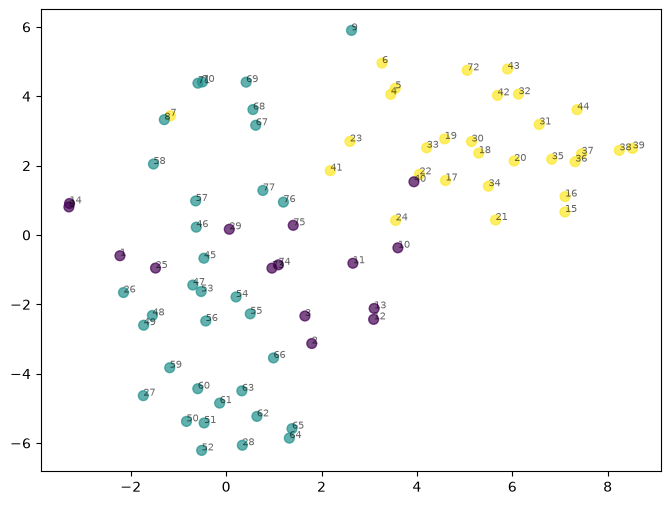

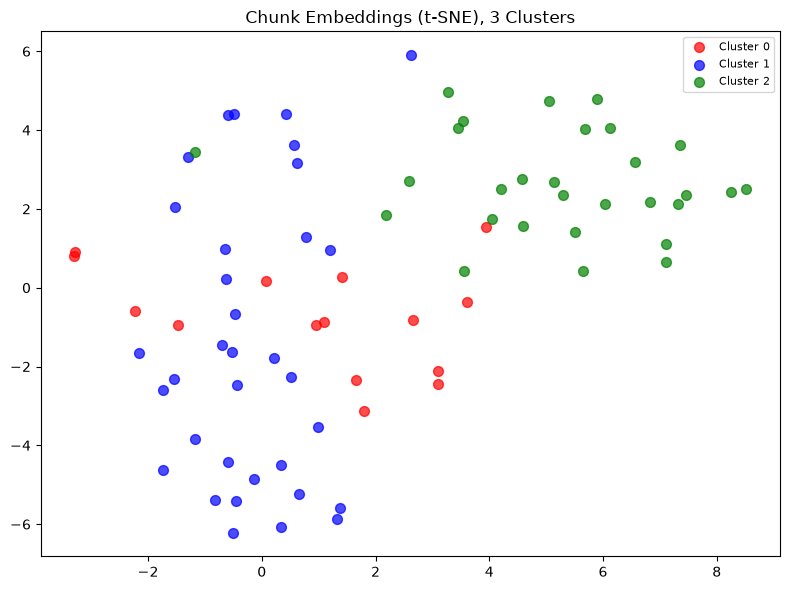

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

N_CLUSTERS = 3

# Reduce embeddings to 2D
reduced = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings) - 1)).fit_transform(np.array(embeddings))

# Plot
plt.figure(figsize=(8, 6))
labels = KMeans(n_clusters=N_CLUSTERS, random_state=42).fit_predict(np.array(embeddings))
plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap="viridis", alpha=0.7, s=50)

for i, (x, y) in enumerate(reduced):
    plt.annotate(str(i), (x, y ), fontsize=7, alpha=0.6)

for cluster_id in range(N_CLUSTERS):
    cluster_chunks = [chunks[i] for i, l in enumerate(labels) if l == cluster_id]
    sample = "\n---\n".join(cluster_chunks[:5])

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        max_tokens=200,
        messages=[{"role": "user", "content": f"Summarize the themese of these text chunks in 2-3 sentences:\n\n-{sample}"}]
    )
    print(f"Cluster {cluster_id} summary: {response.choices[0].message.content}")
#plot with legend
colors = ['red', 'blue', 'green']
plt.figure(figsize=(8, 6))
for cluster_id in range(N_CLUSTERS):
    mask = labels == cluster_id
    plt.scatter(reduced[mask, 0], reduced[mask, 1], c=colors[cluster_id], label=f"Cluster {cluster_id}", alpha=0.7, s=50)
plt.title(f"Chunk Embeddings (t-SNE), {N_CLUSTERS} Clusters")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
#initialize ChromaDB client (persistent storage)
chroma_client = chromadb.PersistentClient(path="./chroma_db_digital_twin")

#initialize ChromaDb in memory client (non-persistent storage)
# chroma_client = chromadb.Client()

collection = chroma_client.get_or_create_collection(
    name="sammy_bio",
)
#empty the collection before adding new data (for testing purposes)
if collection.get()["ids"]:
    collection.delete(collection.get()["ids"])

pprint(collection.get())


{'data': None,
 'documents': [],
 'embeddings': None,
 'ids': [],
 'included': ['metadatas', 'documents'],
 'metadatas': [],
 'uris': None}


In [29]:
#prepare data for storage
#chroma leaves it up to the user to create unique ids for each document.
# ids = [f"chunk_{i}" for i in range(len(chunks))]
# metadatas = [{"source": "sammy_bio", "chunk_index": i} for i in range(len(chunks))]

collection.add(
    ids,
    embeddings,
    metadatas,
    documents = chunks, 
)

#embeddings are not included by default for performance reasons. 
# You can retrieve them by setting include=["embeddings"] in the get() method.
# pprint(collection.get())

pprint(collection.get())

{'data': None,
 'documents': ['Sammy Gutierrez is a Software Engineer, musician, and used to '
               'work as a elementary school music teacher. He lived most of '
               'his life in the greater Houston area but is currently living '
               'in Vail, Colorado.',
               'tly living in Vail, Colorado.\n'
               'He has a Bachelors of Music Education but completed a 1000+ '
               'hour coding bootcamp where he immersed himself in learning '
               'about Software Engineering.',
               'about Software Engineering.\n'
               '\n'
               'Additional Info:\n'
               '- In his time working with students, he has led multiple '
               'ensembles such as choir and percussion ensemble as well as put '
               'on numerous productions such as winter and spring choir '
               'performances, grade level musicals, and even conducted a choir '
               'of 120 5th',
               'co

In [30]:
#generate embedding for a test query
test_query = "skills"

query_embedding = client.embeddings.create(
    model="text-embedding-3-small",
    input = test_query
)
#embed the query using the same model we used for the chunks to ensure compatibility

#Search ChromaDB
chroma_results = collection.query(
    query_embeddings=query_embedding.data[0].embedding,
    n_results=3,
    include=["documents", "metadatas", "distances"]
)

#Verify retreival works - print which chunks were retreived and their content

print("ChromaDB search results:" )
for i, (document, metadata, distance) in enumerate(zip(chroma_results["documents"][0], chroma_results["metadatas"][0], chroma_results["distances"][0])):
    print(f"Result {i+1}:")
    print(f"Source {metadata["source"]}")
    print(f"Chunk Index {metadata["chunk_index"]}")
    print(f"  Document: {document}")
    print(f"  Metadata: {metadata}")
    print(f"  Distance: {distance}")

ChromaDB search results:
Result 1:
Source Sammy's Professional Experience
Chunk Index 1
  Document: approach to problem-solving.
SKILLS
Languages: JavaScript, TypeScript, Python, Ruby, C#, SQL
Frontend: React, Redux, WebSockets, Axios, GraphQL, MUI, HTML, CSS
Backend: Node.js, Express, Passport, Ruby on Rails, REST APIs, PM2
  Metadata: {'chunk_index': 1, 'source': "Sammy's Professional Experience"}
  Distance: 1.1636734008789062
Result 2:
Source Sammy's Professional Experience
Chunk Index 19
  Document: essful delivery of features.

 Unit Testing, AccuRev and +6 skills

Self Employed

Freelance · Freelance

Oct 2022 - Aug 2023 · 11 mos

United States

 Version Control

Wooorld logo
Full Stack Developer

Wooorld · Full-time

Aug 2021 - Sep 2022 · 1 yr 2 mos

Remote
  Metadata: {'chunk_index': 19, 'source': "Sammy's Professional Experience"}
  Distance: 1.3504655361175537
Result 3:
Source Sammy's Professional Experience
Chunk Index 37
  Document: ricular events/performances. 
● Rehearse

Cluster 0 summary: The text highlights Sammy Gutierrez's diverse background as both a software engineer and a musician, showcasing his transition from elementary music education to software development after completing an immersive coding bootcamp. It emphasizes his experience in leading musical ensembles and conducting large performances, juxtaposed with his technical skills in developing web applications for augmented reality. Overall, the themes revolve around the blending of creativity and technology in his career path and his commitment to continuous learning and adaptation.
Cluster 1 summary: The themes of the text highlight efficiency and collaboration in educational settings through the implementation of digital solutions and effective communication. The individual's role is characterized by a commitment to optimizing processes, enhancing music education through innovative curriculum design, and fostering community involvement and collaboration within the school. Their direct y

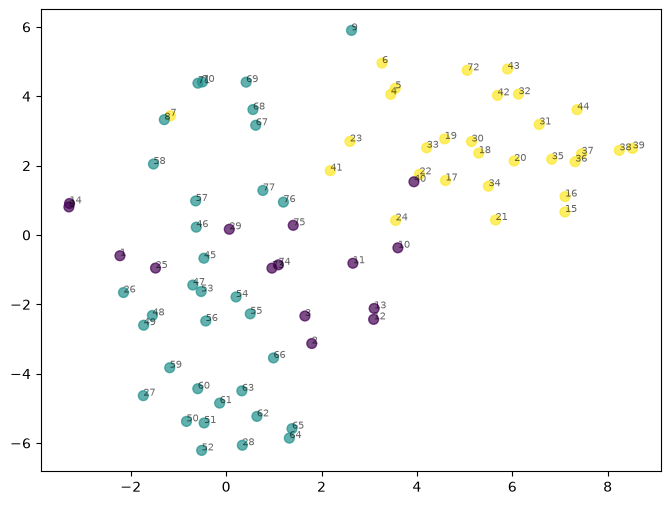

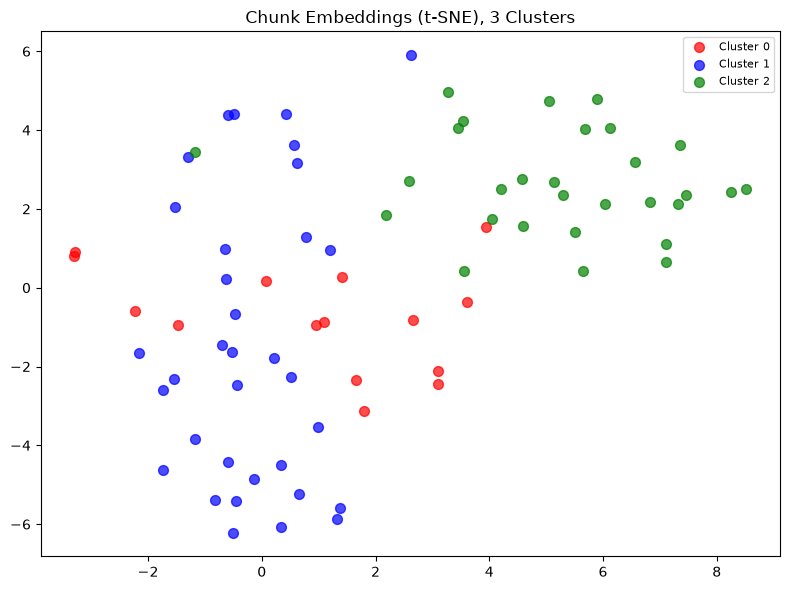

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

N_CLUSTERS = 3

# Reduce embeddings to 2D
reduced = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings) - 1)).fit_transform(np.array(embeddings))

# Plot
plt.figure(figsize=(8, 6))
labels = KMeans(n_clusters=N_CLUSTERS, random_state=42).fit_predict(np.array(embeddings))
plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap="viridis", alpha=0.7, s=50)

for i, (x, y) in enumerate(reduced):
    plt.annotate(str(i), (x, y ), fontsize=7, alpha=0.6)

for cluster_id in range(N_CLUSTERS):
    cluster_chunks = [chunks[i] for i, l in enumerate(labels) if l == cluster_id]
    sample = "\n---\n".join(cluster_chunks[:5])

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        max_tokens=200,
        messages=[{"role": "user", "content": f"Summarize the themese of these text chunks in 2-3 sentences:\n\n-{sample}"}]
    )
    print(f"Cluster {cluster_id} summary: {response.choices[0].message.content}")
#plot with legend
colors = ['red', 'blue', 'green']
plt.figure(figsize=(8, 6))
for cluster_id in range(N_CLUSTERS):
    mask = labels == cluster_id
    plt.scatter(reduced[mask, 0], reduced[mask, 1], c=colors[cluster_id], label=f"Cluster {cluster_id}", alpha=0.7, s=50)
plt.title(f"Chunk Embeddings (t-SNE), {N_CLUSTERS} Clusters")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

In [32]:
system_message = """You are a digital twin of Sammy Gutierrez. When people talk to you, you respond AS Sammy (or Sam) - in first person, using his voice, personality, and knowledge.

IMPORTANT: do not make things up. If you don't know an answer, say you don't know. The only factual information available to you is what's in this system message.
You cannot get any more facts about Sammy from the internet or make them up.

Here's information about Sammy to help you embody him:"""

### Step 3: Prepare the list of tools for the LLM

In [33]:
tools = []

Step 3a: Add tool-calling functionality

In [34]:
#Sets up Pushover and dice rolls as tools

pushover_user = os.getenv("PUSHOVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"

if not pushover_token or not pushover_user:
    raise Exception("Your Pushover Data is missing")

def send_notification(message: str):
    payload = {
        "user": pushover_user,
        "token": pushover_token,
        "message": message
    }    
    requests.post(pushover_url, data=payload)

#sets up variable to describe tool to llm
send_notification_function = {
    "name": "send_notification",
    "description": "Sends a push notification to the real version of you via Pushover on mobile. Use this if the user needs to alert the real-world version you about important events, completed tasks, or time-sensitive information",
    "parameters" : {
        "type": "object",
        "properties": {
            "message": {
                "type": "string",
                "description": "The notification message to send to the user's device"
            }
        },
        "required": ["message"]
    }
}

def dice_roll():
    result = random.randint(1, 6)
    return result

roll_dice_function = {
    "name": "roll_dice",
    "description": "Simulates rolling a six-sided die and returns the result. Use this when the user wants to roll a die for games, decisions, or random number generation.",
    "parameters": {
        "type": "object",
        "properties": {},
        "required": []
    }
}

tools.extend([{"type": "function", "function": send_notification_function}, {"type": "function", "function": roll_dice_function}])

### Step 4: Function to handle LLM Tool calls

In [1]:

def handle_tool_calls(tool_calls):
    tool_call_results = []
    for tool_call in tool_calls:
        if tool_call.function.name == "send_notification":
            args = json.loads(tool_call.function.arguments) 
            message = args.get("message")
            send_notification(message)
            content = f"Notification sent: {message}"
        elif tool_call.function.name == "roll_dice":
            content = f'"Rolled: {dice_roll()}'
        else:
            content = f"Unknown tool call: {tool_call.function.name}"

        tool_call_result = {
            "role": "tool",
            "content": content,
            "tool_call_id": tool_call.id
        }
            
        tool_call_results.append(tool_call_result)
        
    return tool_call_results

### Step 5: Function to process conversation turn

In [ ]:
def respond_ai(message, history):
    #RAG
    #generate embedding for a test query
    
    test_query = "days off"
    query_embedding = client.embeddings.create(
        model="text-embedding-3-small",
        input = message
    )

#Search ChromaDB
    
    chroma_results = collection.query(
        query_embeddings=query_embedding.data[0].embedding,
        n_results=3,
        include=["documents", "metadatas", "distances"]
    )

    # stitch retreived chunks together to create the context for the response
    context = f"""\n---\n""".join(chroma_results["documents"][0])
    print("user message: ", message)
    print("context this turn: \n", context)

    # Update system message with context (for this conversation turn)
    system_message_enhanced = system_message + f""" Context: {context}"""
    print("\n==============================\n")
    print("User Message:", message)
    print("***Retrieved Chunks:")
    for a, b in zip(chroma_results["documents"][0], chroma_results["metadatas"][0]):
        print("------------------------------")
        print(f"<<Document {b['source']} -- Chunk {b['chunk_index']}>>\n{a}\n")

    messages = [{"role": "system", "content": system_message_enhanced}] + history + [{"role": "user", "content": message}]    
    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=messages,
        tools=tools
    )
    message = response.choices[0].message

    #check if model wants to call a tool
    while message.tool_calls:
        tool_results = handle_tool_calls(message.tool_calls)
        messages.append(message)
        messages.extend(tool_results)  # This is a more concise way to add all tool results to messages

        response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=messages,
        tools=tools
    )

    message = response.choices[0].message
    # consider adding a catch to prevent infinite loops if the model keeps calling tools without resolving the conversation
    return message.content

### Step 6: Launch Gradio

In [37]:
gr.ChatInterface(fn=respond_ai).launch(inbrowser=True)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


user message:  what can you tell me about your transition from education into tech?
context this turn: 
 e company and his co-workers.
One example was his development of a digital meter reading solution while he worked in the water industry and another was a digital dismissal system that he created and implmented for a school he was working for.
---
tly living in Vail, Colorado.
He has a Bachelors of Music Education but completed a 1000+ hour coding bootcamp where he immersed himself in learning about Software Engineering.
---
y and DNS setting management.
Software Engineer – GHG Corp | Aug 2023 – Aug 2024
● Led migration of a legacy 20–year–old application from AccuRev to a modern stack using React,
TypeScript, and GraphQL improving maintainability and release reliability


User Message: what can you tell me about your transition from education into tech?
***Retrieved Chunks:
------------------------------
<<Document Sammy's Overview -- Chunk 7>>
e company and his co-workers.
One exam